In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
filePath = 'final_football_model_data.csv'
df = pd.read_csv(filePath)
df

,Date,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,...,B365>2.5_missing,B365<2.5_missing,B365>2.5_implied_prob,B365<2.5_implied_prob,OddsMargin,OU_OddsMargin,OverUnderRatio,Weekend,EarlySeason,RefereeAggression
0,2002-08-27,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,...,1,1,0.526316,0.523560,0.090000,0.994764,0.994764,0,0,0.0
1,2002-08-27,0.0,1.0,A,0.0,1.0,A,A Wiley,10.0,7.0,...,1,1,0.526316,0.523560,0.923077,0.994764,0.994764,0,0,0.0
2,2002-08-28,1.0,1.0,D,0.0,0.0,D,E Wolstenholme,11.0,5.0,...,1,1,0.526316,0.523560,0.371111,0.994764,0.994764,0,0,0.0
3,2002-08-28,0.0,1.0,A,0.0,0.0,D,M Halsey,20.0,9.0,...,1,1,0.526316,0.523560,0.230769,0.994764,0.994764,0,0,0.0
4,2002-08-28,1.0,1.0,D,0.0,0.0,D,C Foy,12.0,10.0,...,1,1,0.526316,0.523560,1.428571,0.994764,0.994764,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7896,2023-12-30,3.0,2.0,H,2.0,1.0,H,S Attwell,19.0,9.0,...,0,0,0.636943,0.425532,0.181333,0.668085,0.668085,1,0,5.0
7897,2023-12-31,2.0,1.0,H,1.0,1.0,D,J Smith,15.0,13.0,...,0,0,0.578035,0.480769,3.387097,0.831731,0.831731,1,0,3.0
7898,2023-12-31,3.0,1.0,H,1.0,0.0,H,S Hooper,12.0,24.0,...,0,0,0.714286,0.347222,0.437500,0.486111,0.486111,1,0,5.7
7899,2024-01-01,4.0,2.0,H,0.0,0.0,D,A Taylor,34.0,5.0,...,0,0,0.694444,0.370370,0.207143,0.533333,0.533333,0,1,4.7


              precision    recall  f1-score   support

           0       0.53      0.57      0.55       765
           1       0.57      0.54      0.55       816

    accuracy                           0.55      1581
   macro avg       0.55      0.55      0.55      1581
weighted avg       0.55      0.55      0.55      1581



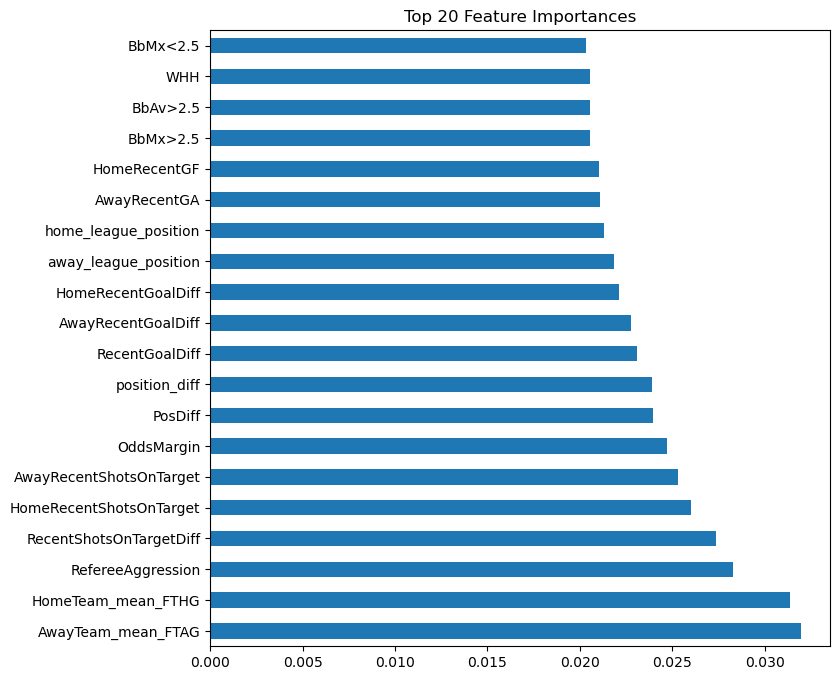

In [13]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',  
    'HC', 'AC',               
    'HF', 'AF',               
    'HY', 'AY',               
    'HR', 'AR',               
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts',
    'BTTS', 'Home_2plus', 'Away_2plus'
    ]

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['GoalsOver2_5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances')
plt.show()

In [14]:
print(feat_importances)

IWH                  0.018822
IWD                  0.016641
IWA                  0.020082
WHH                  0.020524
WHD                  0.017413
                       ...   
OU_OddsMargin        0.006830
OverUnderRatio       0.005806
Weekend              0.004003
EarlySeason          0.004274
RefereeAggression    0.028306
Length: 148, dtype: float64


In [15]:
feat_importances.to_string('feature_importances.txt')

              precision    recall  f1-score   support

           0       0.51      0.52      0.51       783
           1       0.52      0.51      0.51       798

    accuracy                           0.51      1581
   macro avg       0.51      0.51      0.51      1581
weighted avg       0.51      0.51      0.51      1581



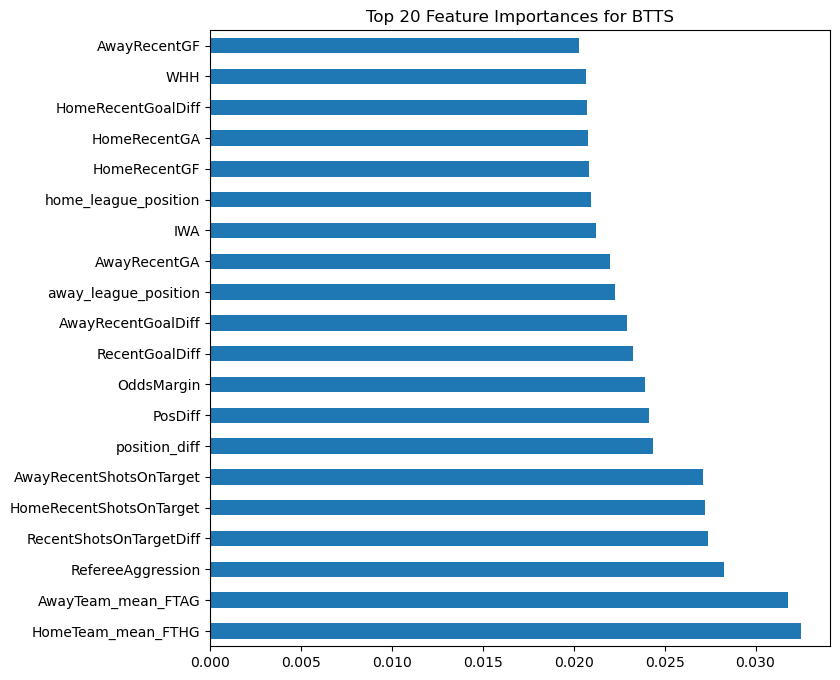

In [16]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',  
    'HC', 'AC',               
    'HF', 'AF',               
    'HY', 'AY',               
    'HR', 'AR',               
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts',
    'BTTS', 'Home_2plus', 'Away_2plus'
    ]

df['BTTS'] = ((df['FTHG'] > 0) & (df['FTAG'] > 0)).astype(int)

X = df.drop(columns=cols_to_drop + ['BTTS', 'Home_2plus', 'Away_2plus'], errors='ignore')
y = df['BTTS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances for BTTS')
plt.show()

              precision    recall  f1-score   support

           0       0.63      0.76      0.69       876
           1       0.60      0.45      0.52       705

    accuracy                           0.62      1581
   macro avg       0.62      0.61      0.60      1581
weighted avg       0.62      0.62      0.61      1581



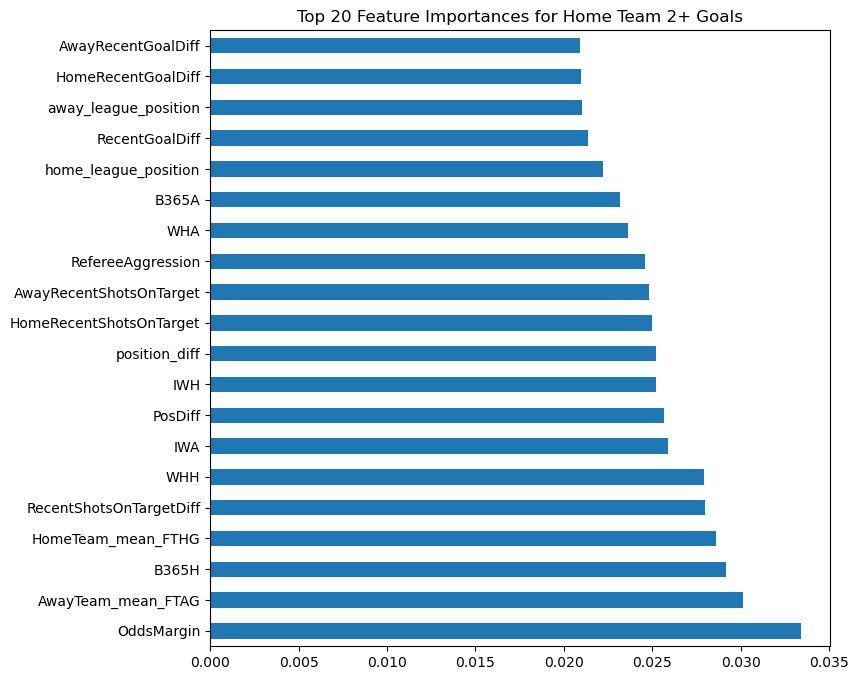

In [17]:
df['Home_2plus'] = (df['FTHG'] >= 2).astype(int)

X = df.drop(columns=cols_to_drop + ['BTTS', 'Home_2plus', 'Away_2plus'], errors='ignore')
y = df['Home_2plus']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances for Home Team 2+ Goals')
plt.show()

              precision    recall  f1-score   support

           0       0.71      0.90      0.79      1075
           1       0.51      0.23      0.32       506

    accuracy                           0.68      1581
   macro avg       0.61      0.56      0.55      1581
weighted avg       0.65      0.68      0.64      1581



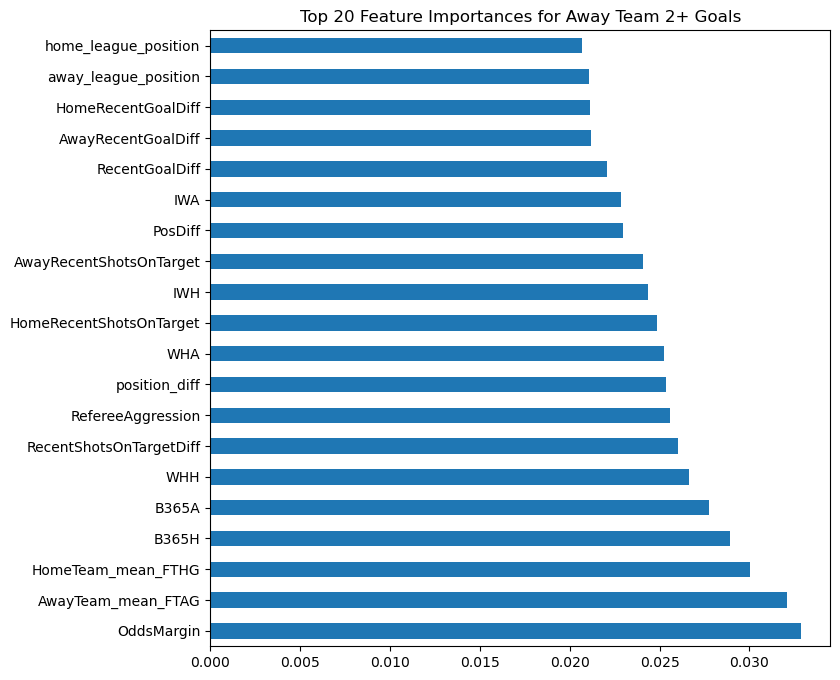

In [18]:
df['Away_2plus'] = (df['FTAG'] >= 2).astype(int)

X = df.drop(columns=cols_to_drop + ['BTTS', 'Home_2plus', 'Away_2plus'], errors='ignore')
y = df['Away_2plus']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances for Away Team 2+ Goals')
plt.show()